In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

Task 1. Simulate a path of the Wiener process. Number of end-points of the grid including $T$ is $N=100$, length of the interval $[0, T]$ in time units is 1, time increment is $\Delta = T/N$. Plot the path.

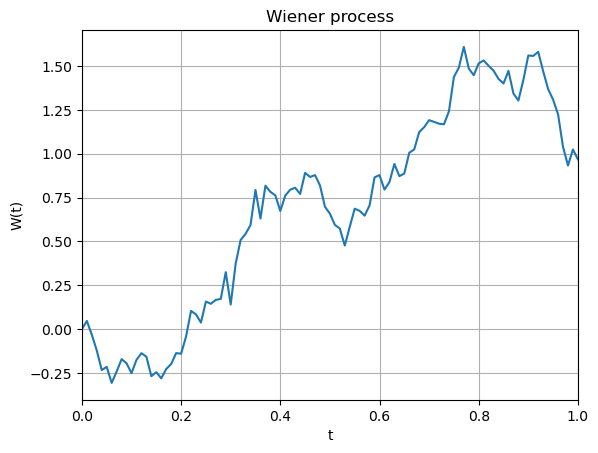

In [3]:
def WienerRandomValue(t):
    return np.sqrt(t) * np.random.normal(0, 1)


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

N = 100
T = 1
t_data, w_data = WienerProcess(N, T)

plt.plot(t_data, w_data)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.xlim(0.0, 1.0)
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 2. Using the random walk algorithm simulate three paths of the Wiener process as the limit of a random walk for different $n=10, 100, 1000$. Plot the paths in one figure, add the legend.

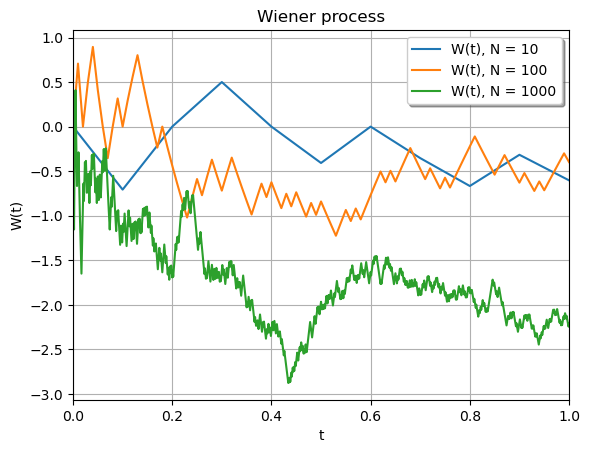

In [3]:
def RandomValueP(p):
    assert p > 0.0 and p < 1.0, '0 < p < 1'

    rand = np.random.uniform(0, 1)
    if rand <= p:
        return 1
    else:
        return -1

def RandomWalk(p, N):
    t_data = np.linspace(0, 1, N + 1)
    w_data = np.zeros(N + 1)
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] * np.sqrt(i / (i + 1)) + RandomValueP(p) / np.sqrt(i + 1)
    return t_data, w_data

p = 0.5
N = [10, 100, 1000]
for k in N:
    t_data, w_data = RandomWalk(p, k)
    plt.plot(t_data, w_data, label = f"W(t), N = {k}")

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 3. Using the the Karhunen-Loeve expansion simulate three paths of the Wiener process with
$n = 10, 50, 100$ terms. Plot the paths in one figure, add legends.

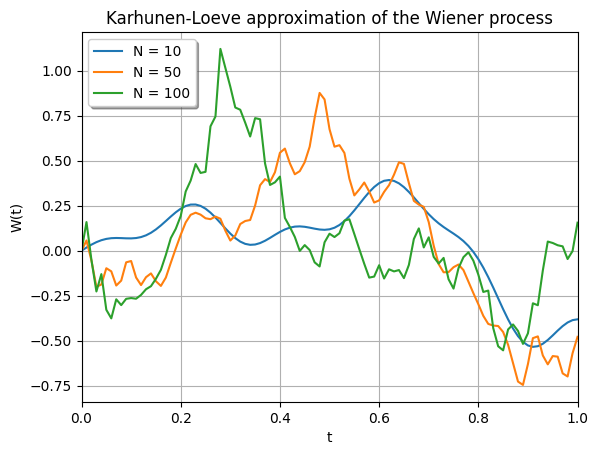

In [ ]:
def phi(k, t, T):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def KarhunenLoeveApprox(T, Nt, Nz):
    z_data = np.random.normal(0, 1, size = Nz)
    t_data = np.linspace(0, T, Nt + 1)
    k = np.arange(0, len(z_data)) + 1
    w_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        phi_data = phi(k, t_data[i], T)
        w_data[i] = np.dot(z_data, phi_data)
    return t_data, w_data

T = 1
Nt = 100
Nz = [10, 50, 100]

for k in Nz:
    t_data, w_data = KarhunenLoeveApprox(T, Nt, k)
    plt.plot(t_data, w_data, label = f'N = {k}')

plt.legend(loc = 'upper left', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Karhunen-Loeve approximation of the Wiener process")
plt.grid(True)
plt.show()

Task 4. Plot a trajectory of the geometric Brownian motion obtained from the simulation of the path of the Wiener process, $r=1$ (interest rate) and $\sigma = 0.5$ (volatility).

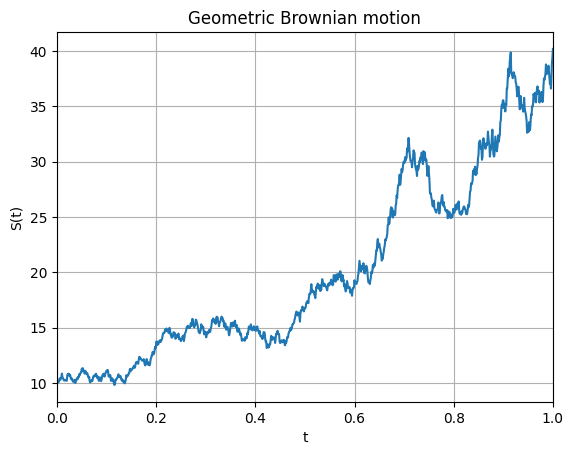

In [ ]:
def GeometricBrownianMotion(S0, r, sigma, T):
    Nt = 1000
    t_data = np.linspace(0, T, Nt + 1)
    s_data = np.zeros(Nt + 1)
    s_data[0] = S0
    dt = T / Nt
    for i in range(1, Nt + 1):
        s_data[i] = s_data[i-1] * np.exp((r - sigma**2 / 2)* dt + sigma * WienerRandomValue(dt))
    return t_data, s_data

S0 = 10
r = 1
sigma = 0.5
T = 1

t_data, s_data = GeometricBrownianMotion(S0, r, sigma, T)
plt.plot(t_data, s_data)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("Geometric Brownian motion")
plt.grid(True)
plt.show()

Task 5. Plot a trajectory of the the Brownian bridge starting at $x$ at time $0$ and terminating its run at $y =-1$ at time $T$ obtained from the simulation of the path of the Wiener process. Add markers for start and end points.

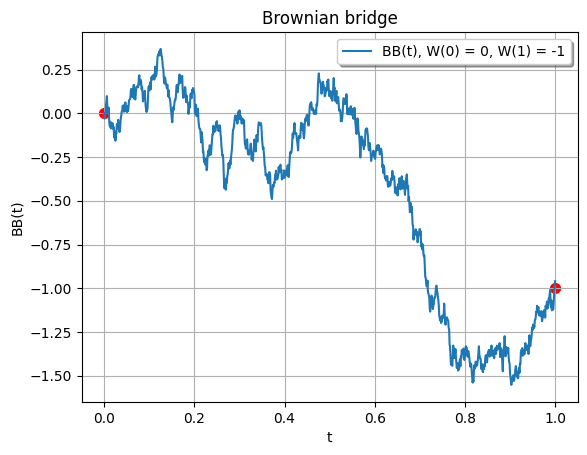

In [ ]:
def BrownianBridge(x, y, t0, T):
    Nt = 1000
    t_data, w_data = WienerProcess(Nt, T)
    dt = T/Nt
    bb_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        bb_data[i] = x + w_data[i] - (t_data[i] - t0) / (T - t0) * (w_data[Nt - 1] - y + x)
    return t_data, bb_data

x = 0
y = -1
t0 = 0
T = 1
t_data, bb_data = BrownianBridge(x, y, t0, T)

plt.plot(t_data, bb_data, label = f"BB(t), W({t0}) = {x}, W({T}) = {y}")
plt.scatter ( t0, x, color = "red", s = 50)
plt.scatter ( T, y, color = "red", s = 50)
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("BB(t)")
plt.title("Brownian bridge")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Let us consider a random walk $X = (X_n)_{n \geq 0}$:
$$
X_n = \sum_{k=1}^n \xi_k, \quad \xi_k =
\begin{cases}
1, &\text{with probability $\frac12$}; \\
-1, &\text{with probability $\frac12$}.
\end{cases}
$$
$$
\mathbb{E}\xi_k = 0, \quad \mathrm{Var}\, \xi_k = 1.
$$

Plot $(X_{t_i})_{t_i = \frac{i}{n}}$ so that $t_i$ takes values in $[0,\, 1]$.

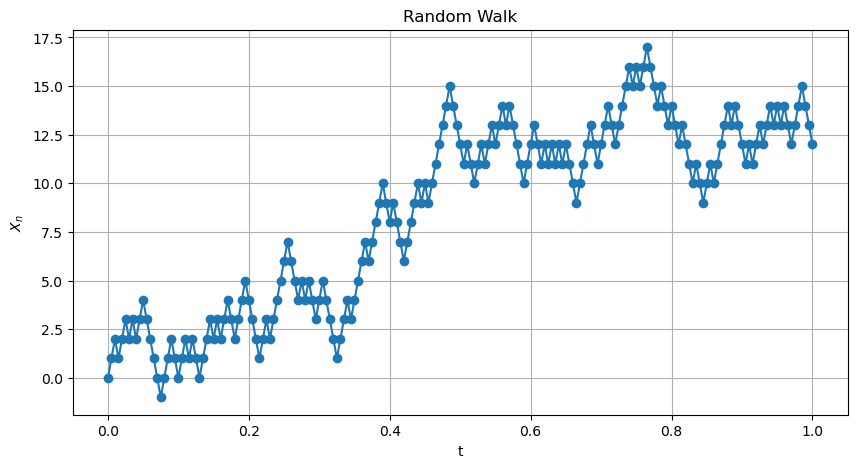

In [7]:
def RandomWalk(N, p=[0.5, 0.5]):

    xi = np.random.choice([-1, 1], size=N, p=p)

    # Вычисляем случайное блуждание
    X = np.cumsum(xi) 

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)

    # Создаем массив t
    t = np.linspace(0, 1, N + 1)

    # Строим график
    plt.figure(figsize=(10, 5))
    plt.plot(t, X, marker='o', linestyle='-')
    plt.title('Random Walk')
    plt.xlabel('t')
    plt.ylabel('$X_n$')
    plt.grid()
    plt.show()
RandomWalk(200)

Exercise 2. Let $H = (H_n)_{n \geq 1}$ be the player's bet at the $n$-th step, i.e. his winnings at this step are equal to $H_n (X_n - X_{n-1}) = H_n \Delta X_n$.

Plot an accumulated winnings of player $Y_n$ at step $n \geq 1$.


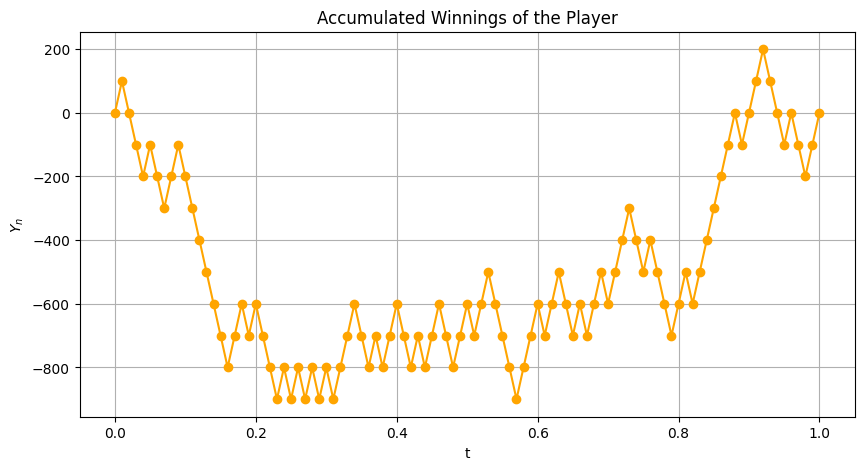

In [ ]:
def random_walk_with_bets(n, H):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=n, p=[0.5, 0.5])

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Вычисляем накопленные выигрыши
    Y = np.zeros(n + 1)  # Начинаем с 0
    for i in range(1, n + 1):
        Y[i] = Y[i - 1] + H * (X[i] - X[i - 1])  # Y_n = Y_{n-1} + H * ΔX_n

    # Создаем массив t
    t = np.linspace(0, 1, n + 1)  # n + 1 точек для t_i

    # Строим график накопленных выигрышей
    plt.figure(figsize=(10, 5))
    plt.plot(t, Y, marker='o', linestyle='-', color='orange')
    plt.title('Accumulated Winnings of the Player')
    plt.xlabel('n')
    plt.ylabel('$Y_n$')
    plt.grid()
    plt.show()

# Пример вызова функции с n = 100 и H = 1
random_walk_with_bets(100, H=100)

# Задачи

Задача 1. Квадратичная вариация (Раздел 1.1.2)

Для траектории винеровского процесса при $T=1$ и разного числа интервалов разбиения $\{10,100,1000,10000\}$:

1. Вычислите сумму квадратов приращений $$ S_n= ∑_{k=0}^{n−1}​ ∣W(t_{k+1} )−W(t_k​ )∣^2.$$

2. Постройте график зависимости суммы $S_n$ от числа интервалов разбиения (столбчатую диаграмму).

3. Сделайте выводы.

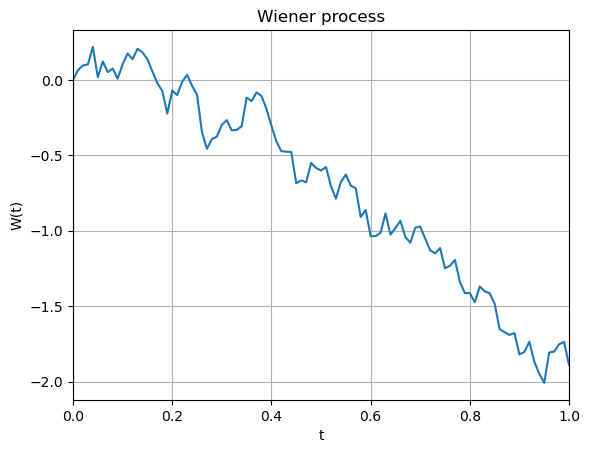

In [8]:
def WienerRandomValue(t):
    return np.sqrt(t) * np.random.normal(0, 1)


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

def sum_of_WienerProcess(N: list):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    cumsum = 0
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
        cumsum += (w_data[i] + w_data[i - 1])**2
    return cumsum


N = 100
T = 1
t_data, w_data = WienerProcess(N, T)

plt.plot(t_data, w_data)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.xlim(0.0, 1.0)
plt.title("Wiener process")
plt.grid(True)
plt.show()

Задача 2. Эмпирическая ковариационная функция (Раздел 1.1.3)

Для винеровского процесса теоретическая ковариация между состояниями в моменты времени $s$ и $t$ равна $\min(s,t)$.

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Вычислите выборочную ковариацию между точками $t=0.5$ и $t=T$ и сравните полученное число с теоретическим значением $0.5$.

3. Сделайте выводы.

Параметры: N = 500, T = 1.0
Моменты времени: t1 = 0.5, t2 = 1.0
------------------------------
Теоретическая ковариация min(0.5, 1.0) = 0.5
Эмпирическая ковариация                = 0.53892
Абсолютная ошибка                      = 0.03892
------------------------------


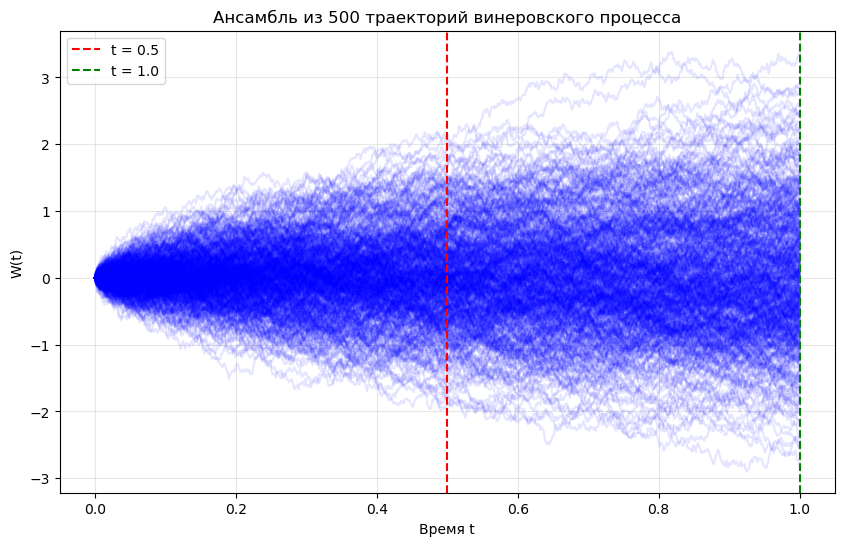

In [ ]:

N_trajectories = 500  # Количество траекторий
T = 1.0               # Конечное время 
num_steps = 1000      # Количество шагов по времени
dt = T / num_steps    # Шаг по времени
t = np.linspace(0, T, num_steps + 1) 

dW = np.random.normal(loc=0.0, scale=np.sqrt(dt), size=(N_trajectories, num_steps))

W = np.cumsum(dW, axis=1)
W = np.hstack((np.zeros((N_trajectories, 1)), W))

t1 = 0.5
t2 = T

idx1 = int(t1 / dt)
idx2 = int(t2 / dt)

W_t1 = W[:, idx1] 
W_t2 = W[:, idx2]

cov_matrix = np.cov(W_t1, W_t2)
cov_empirical = cov_matrix[0, 1]

cov_theoretical = min(t1, t2)

print(f"Параметры: N = {N_trajectories}, T = {T}")
print(f"Моменты времени: t1 = {t1}, t2 = {t2}")
print("-" * 30)
print(f"Теоретическая ковариация min({t1}, {t2}) = {cov_theoretical}")
print(f"Эмпирическая ковариация                = {cov_empirical:.5f}")
print(f"Абсолютная ошибка                      = {abs(cov_empirical - cov_theoretical):.5f}")
print("-" * 30)

plt.figure(figsize=(10, 6))
plt.plot(t, W.T, alpha=0.1, color='blue')
plt.axvline(x=t1, color='r', linestyle='--', label=f't = {t1}')
plt.axvline(x=t2, color='g', linestyle='--', label=f't = {t2}')
plt.title(f'Ансамбль из {N_trajectories} траекторий винеровского процесса')
plt.xlabel('Время t')
plt.ylabel('W(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Задача 3. Тестирование мартингального свойства (Раздел 1.1.5)

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Выберите фиксированный момент времени $s=0.4$.

3. Для всех сгенерированных траекторий, проходящих через определенный узкий диапазон значений в момент $s$, вычислите среднее арифметическое их значений в финальный момент $T$.

4. Сравните полученное среднее арифметическое со значением процесса в момент $s$.

5. Сделайте выводы. Проанализовать как диапозон влияет на результат.

Момент s = 0.4, Финальный момент T = 1.0
Целевое значение W(s) ≈ 0.0
----------------------------------------------------------------------
Диапазон (eps)  | Кол-во траек.   | Ср. W(s)   | Ср. W(T)   | Разность  
----------------------------------------------------------------------
0.05            | 28              | 0.0003     | 0.0292     | 0.0289    
0.10            | 62              | 0.0094     | 0.0222     | 0.0128    
0.20            | 128             | -0.0159    | -0.0861    | -0.0703   
0.50            | 282             | -0.0122    | -0.0520    | -0.0398   
1.00            | 445             | -0.0343    | -0.0872    | -0.0529   
----------------------------------------------------------------------


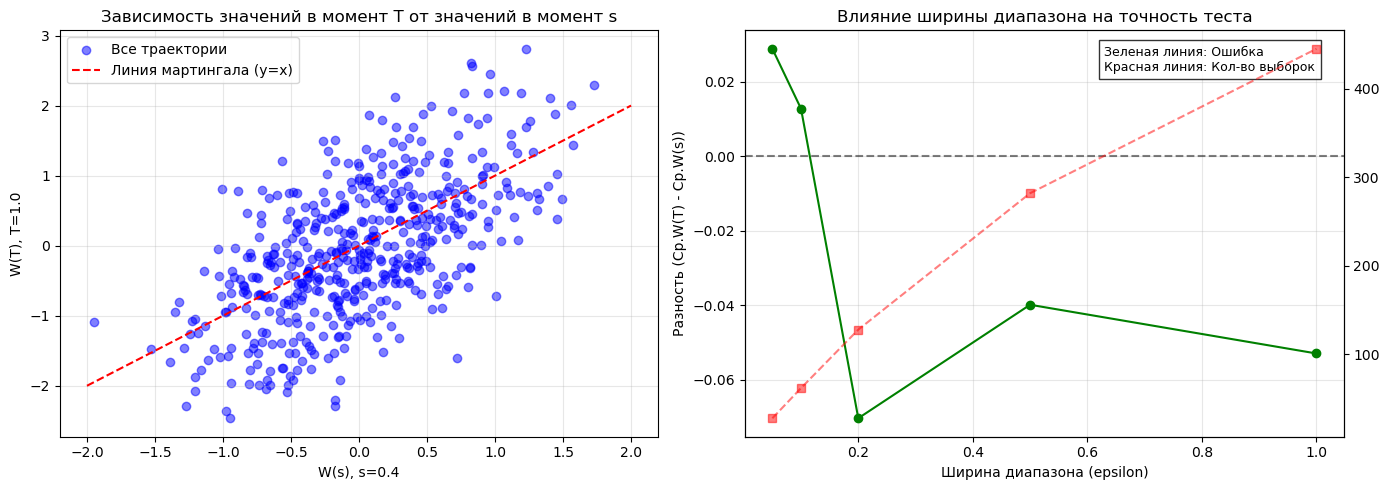

In [4]:
N_trajectories = 500  # Количество траекторий
T = 1.0               # Финальное время
s = 0.4               # Фиксированный момент времени
num_steps = 1000      
dt = T / num_steps
t = np.linspace(0, T, num_steps + 1)

dW = np.random.normal(loc=0.0, scale=np.sqrt(dt), size=(N_trajectories, num_steps))
W = np.cumsum(dW, axis=1)
W = np.hstack((np.zeros((N_trajectories, 1)), W))

idx_s = int(s / dt)
idx_T = int(T / dt)

W_s_all = W[:, idx_s]
W_T_all = W[:, idx_T]

target_value = 0.0

epsilons = [0.05, 0.1, 0.2, 0.5, 1.0]

results = []

print(f"Момент s = {s}, Финальный момент T = {T}")
print(f"Целевое значение W(s) ≈ {target_value}")
print("-" * 70)
print(f"{'Диапазон (eps)':<15} | {'Кол-во траек.':<15} | {'Ср. W(s)':<10} | {'Ср. W(T)':<10} | {'Разность':<10}")
print("-" * 70)

for eps in epsilons:
    mask = np.abs(W_s_all - target_value) < eps
    count = np.sum(mask)
    
    if count > 0:
        mean_W_s = np.mean(W_s_all[mask])
        mean_W_T = np.mean(W_T_all[mask])
        diff = mean_W_T - mean_W_s
        results.append((eps, count, mean_W_s, mean_W_T, diff))
        
        print(f"{eps:<15.2f} | {count:<15} | {mean_W_s:<10.4f} | {mean_W_T:<10.4f} | {diff:<10.4f}")
    else:
        print(f"{eps:<15.2f} | {0:<15} | {'N/A':<10} | {'N/A':<10} | {'N/A':<10}")
        results.append((eps, 0, np.nan, np.nan, np.nan))

print("-" * 70)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(W_s_all, W_T_all, alpha=0.5, color='blue', label='Все траектории')
axs[0].plot([-2, 2], [-2, 2], 'r--', label='Линия мартингала (y=x)')
axs[0].set_xlabel(f'W(s), s={s}')
axs[0].set_ylabel(f'W(T), T={T}')
axs[0].set_title('Зависимость значений в момент T от значений в момент s')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

eps_vals = [r[0] for r in results if r[1] > 0]
diff_vals = [r[4] for r in results if r[1] > 0]
counts = [r[1] for r in results if r[1] > 0]

axs[1].plot(eps_vals, diff_vals, 'o-', color='green', label='Ошибка (Bias)')
axs[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axs[1].set_xlabel('Ширина диапазона (epsilon)')
axs[1].set_ylabel('Разность (Ср.W(T) - Ср.W(s))')
axs[1].set_title('Влияние ширины диапазона на точность теста')
axs[1].grid(True, alpha=0.3)

axs[1].twinx().plot(eps_vals, counts, 's--', color='red', alpha=0.5, label='Кол-во точек')
axs[1].text(0.6, 0.9, 'Зеленая линия: Ошибка\nКрасная линия: Кол-во выборок', 
            transform=axs[1].transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Задача 4. Анализ независимости приращений (Раздел 1.2)

1. Выберите два непересекающихся интервала $[t_1, t_2​]$ и $[t_3, t_4​]$.
2. Сгенерируйте $M$ траекторий и вычислите приращения
$ΔW_1 =W(t_2)−W(t_1)$ и $ΔW_2 =W(t_4)−W(t_3)$.

3. Постройте диаграмму рассеяния (scatter plot) для $(ΔW_1, ΔW_2)$ и вычислите коэффициент корреляции.

4. Сравните полученное значение с нулем и сделайте выводы.

Количество траекторий: M = 1000
Интервал 1: [0.2, 0.4], длина = 0.2
Интервал 2: [0.6, 0.8], длина = 0.20000000000000007
----------------------------------------------------------------------
Приращения: ΔW1 = W(0.4) - W(0.2)
            ΔW2 = W(0.8) - W(0.6)
----------------------------------------------------------------------
Статистика ΔW1: среднее = 0.00411, стандартное отклонение = 0.45356
Статистика ΔW2: среднее = 0.00831, стандартное отклонение = 0.42892
----------------------------------------------------------------------
Коэффициент корреляции Пирсона: -0.042278
Теоретическое значение (для независимых величин): 0.0
Абсолютное отклонение от нуля: 0.042278


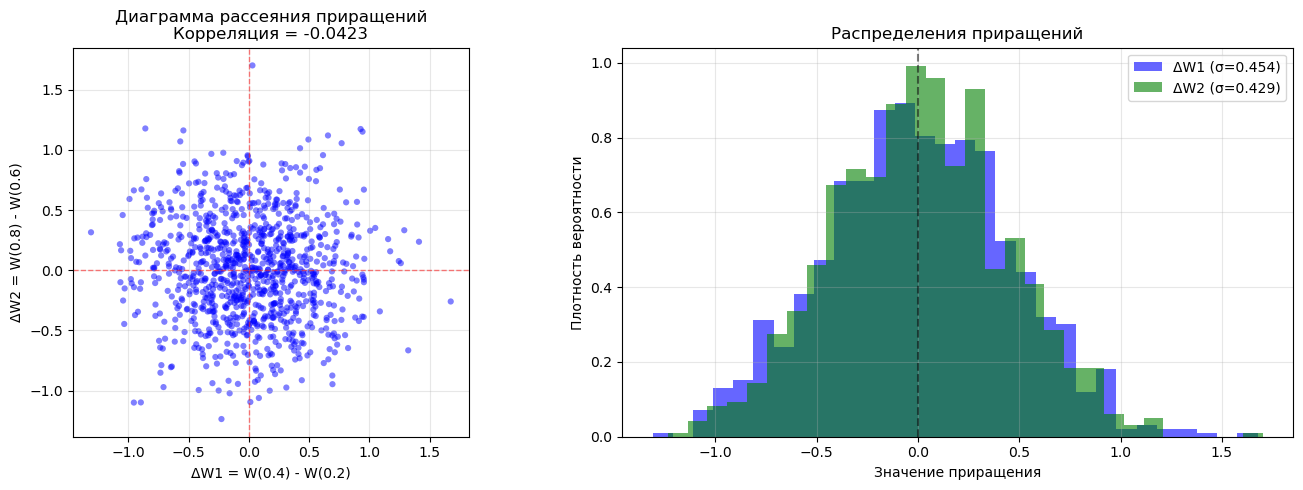


Дополнительный анализ: корреляция для разных пар интервалов
----------------------------------------------------------------------
Пара 1: [0.1, 0.2] и [0.3, 0.4] -> Корреляция = 0.022441
Пара 2: [0.2, 0.4] и [0.6, 0.8] -> Корреляция = -0.042278
Пара 3: [0.0, 0.3] и [0.7, 1.0] -> Корреляция = -0.015386
Пара 4: [0.4, 0.5] и [0.5, 0.6] -> Корреляция = 0.013426
----------------------------------------------------------------------


In [9]:

M = 1000            # Количество траекторий
T = 1.0             # Конечное время
num_steps = 1000    
dt = T / num_steps
t = np.linspace(0, T, num_steps + 1)

t1, t2 = 0.2, 0.4
t3, t4 = 0.6, 0.8

idx_t1 = int(t1 / dt)
idx_t2 = int(t2 / dt)
idx_t3 = int(t3 / dt)
idx_t4 = int(t4 / dt)

dW = np.random.normal(loc=0.0, scale=np.sqrt(dt), size=(M, num_steps))
W = np.cumsum(dW, axis=1)
W = np.hstack((np.zeros((M, 1)), W))

Delta_W1 = W[:, idx_t2] - W[:, idx_t1]  # Приращение на [t1, t2]
Delta_W2 = W[:, idx_t4] - W[:, idx_t3]  # Приращение на [t3, t4]

correlation = np.corrcoef(Delta_W1, Delta_W2)[0, 1]

print(f"Количество траекторий: M = {M}")
print(f"Интервал 1: [{t1}, {t2}], длина = {(t2 - t1)}")
print(f"Интервал 2: [{t3}, {t4}], длина = {t4 - t3}")
print("-" * 70)
print(f"Приращения: ΔW1 = W({t2}) - W({t1})")
print(f"            ΔW2 = W({t4}) - W({t3})")
print("-" * 70)
print(f"Статистика ΔW1: среднее = {np.mean(Delta_W1):.5f}, "
      f"стандартное отклонение = {np.std(Delta_W1):.5f}")
print(f"Статистика ΔW2: среднее = {np.mean(Delta_W2):.5f}, "
      f"стандартное отклонение = {np.std(Delta_W2):.5f}")
print("-" * 70)
print(f"Коэффициент корреляции Пирсона: {correlation:.6f}")
print(f"Теоретическое значение (для независимых величин): 0.0")
print(f"Абсолютное отклонение от нуля: {abs(correlation):.6f}")
print("=" * 70)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(Delta_W1, Delta_W2, alpha=0.5, color='blue', s=20, edgecolors='none')
axs[0].axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
axs[0].axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
axs[0].set_xlabel(f'ΔW1 = W({t2}) - W({t1})')
axs[0].set_ylabel(f'ΔW2 = W({t4}) - W({t3})')
axs[0].set_title(f'Диаграмма рассеяния приращений\nКорреляция = {correlation:.4f}')
axs[0].grid(True, alpha=0.3)
axs[0].set_aspect('equal', 'box')

axs[1].hist(Delta_W1, bins=30, alpha=0.6, color='blue', label=f'ΔW1 (σ={np.std(Delta_W1):.3f})', density=True)
axs[1].hist(Delta_W2, bins=30, alpha=0.6, color='green', label=f'ΔW2 (σ={np.std(Delta_W2):.3f})', density=True)
axs[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axs[1].set_xlabel('Значение приращения')
axs[1].set_ylabel('Плотность вероятности')
axs[1].set_title('Распределения приращений')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nДополнительный анализ: корреляция для разных пар интервалов")
print("-" * 70)

interval_pairs = [
    (0.1, 0.2, 0.3, 0.4),
    (0.2, 0.4, 0.6, 0.8),
    (0.0, 0.3, 0.7, 1.0),
    (0.4, 0.5, 0.5, 0.6),  # Граничный случай (t2 = t3)
]

for i, (a1, a2, a3, a4) in enumerate(interval_pairs, 1):
    idx_a1 = int(a1 / dt)
    idx_a2 = int(a2 / dt)
    idx_a3 = int(a3 / dt)
    idx_a4 = int(a4 / dt)
    
    dW1 = W[:, idx_a2] - W[:, idx_a1]
    dW2 = W[:, idx_a4] - W[:, idx_a3]
    
    corr = np.corrcoef(dW1, dW2)[0, 1]
    print(f"Пара {i}: [{a1}, {a2}] и [{a3}, {a4}] -> Корреляция = {corr:.6f}")

print("-" * 70)

Задача 5. Точность разложения Карунена-Лоэва (Раздел 1.2.3)

1. Реализуйте аппроксимацию винеровской траектории, используя $n=10, 100, 1000$ слагаемых.
2. Рассчитайте среднеквадратичную ошибку между прямой симуляцией и аппроксимацией Карунена-Лоэва.

3. Постройте график зависимости ошибки при увеличении числа членов ряда $n$.
4. Сделайте выводы.


Параметры: T = 1.0, точек по времени = 1001
Эталон: прямая симуляция винеровского процесса
----------------------------------------------------------------------
n (членов)   | MSE             | RMSE           
----------------------------------------------------------------------
1            | 0.814622        | 0.902564       
2            | 0.888342        | 0.942519       
5            | 0.863489        | 0.929241       
10           | 0.875831        | 0.935858       
20           | 0.885162        | 0.940831       
50           | 0.888044        | 0.942361       
100          | 0.889071        | 0.942906       
200          | 0.889772        | 0.943277       
500          | 0.890099        | 0.943451       
1000         | 0.890195        | 0.943501       


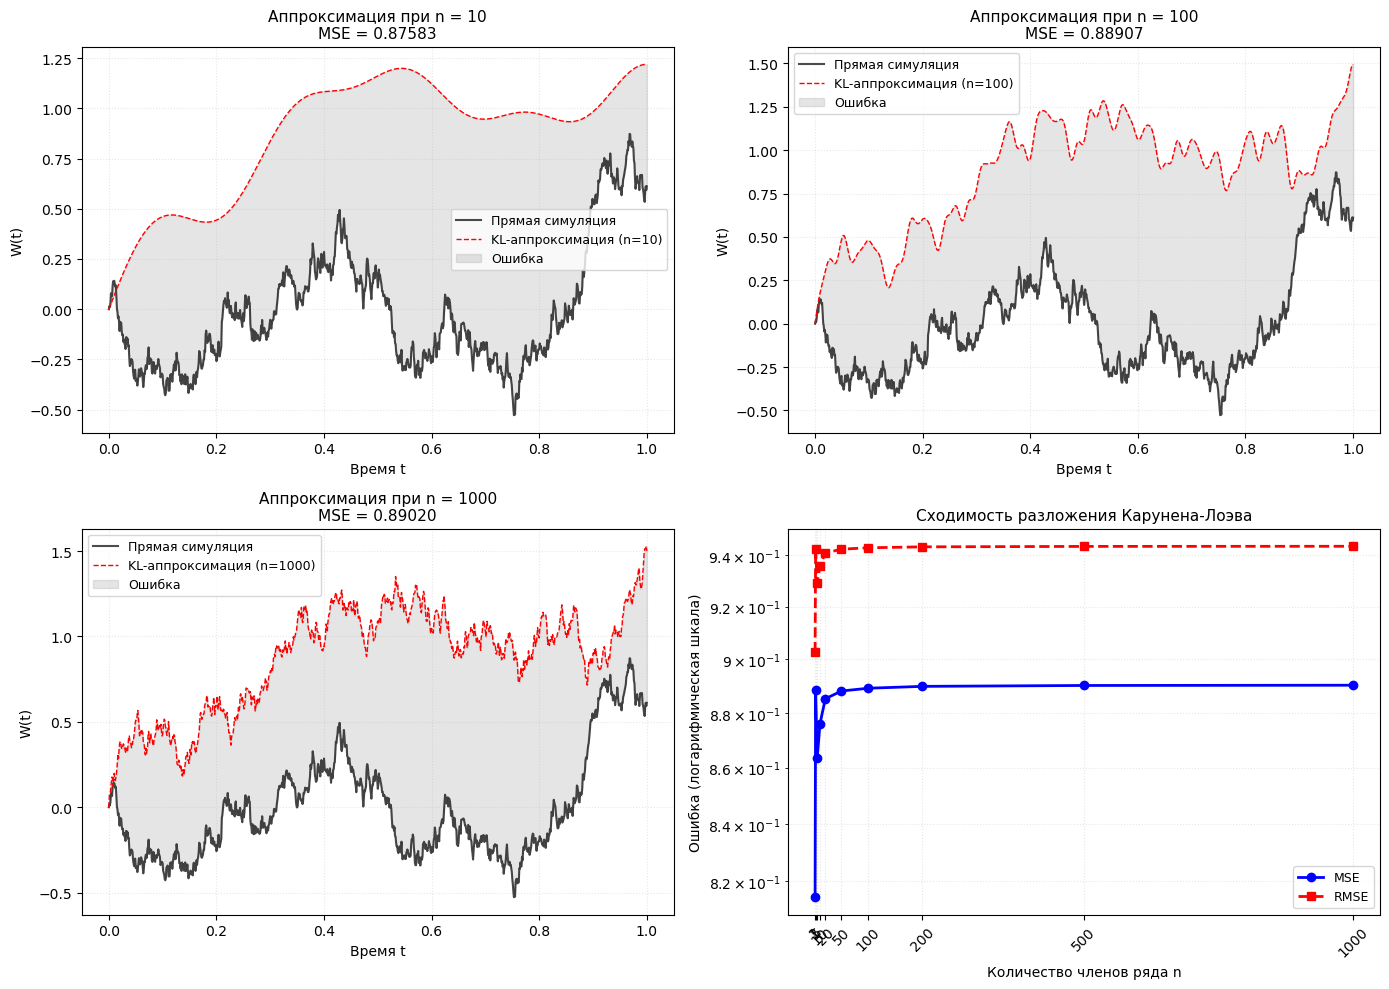


Теоретическая оценка остаточной дисперсии:
----------------------------------------------------------------------
Остаточная дисперсия = Σ_{k=n+1}^{∞} λ_k ≈ T² / (π² * n)
----------------------------------------------------------------------
n = 10   | Теор. остаток ≈ 0.010132 | Эмп. MSE = 0.875831
n = 100  | Теор. остаток ≈ 0.001013 | Эмп. MSE = 0.889071
n = 1000 | Теор. остаток ≈ 0.000101 | Эмп. MSE = 0.890195
----------------------------------------------------------------------


In [12]:

T = 1.0                    # Конечное время
num_steps = 1000           # Количество точек дискретизации по времени
t = np.linspace(0, T, num_steps + 1) 

def simulate_wiener_direct(T, num_steps, seed=None):
    """Генерация траектории методом накопления нормальных приращений"""
    if seed is not None:
        np.random.seed(seed)
    dt = T / num_steps
    dW = np.random.normal(0, np.sqrt(dt), num_steps)
    W = np.cumsum(dW)
    W = np.insert(W, 0, 0) 
    return W

def karhunen_loeve_approx(t, T, n, Z=None, seed=None):
    """
    Аппроксимация винеровского процесса через разложение Карунена-Лоэва.
    
    W(t) ≈ Σ_{k=1}^{n} Z_k * sqrt(λ_k) * e_k(t)
    
    где:
    - λ_k = T² / ((k - 0.5)² * π²)  — собственные значения
    - e_k(t) = sqrt(2/T) * sin((k - 0.5) * π * t / T)  — собственные функции
    - Z_k ~ N(0, 1) — независимые стандартные нормальные СВ
    """
    if Z is None:
        if seed is not None:
            np.random.seed(seed)
        Z = np.random.normal(0, 1, n)
    
    W_approx = np.zeros_like(t)
    
    for k in range(1, n + 1):
        lambda_k = (T ** 2) / ((k - 0.5) ** 2 * np.pi ** 2)
        e_k = np.sqrt(2 / T) * np.sin((k - 0.5) * np.pi * t / T)
        W_approx += Z[k-1] * np.sqrt(lambda_k) * e_k
    
    return W_approx

def compute_mse(W_true, W_approx):
    """MSE между истинной и аппроксимированной траекторией"""
    return np.mean((W_true - W_approx) ** 2)
W_true = simulate_wiener_direct(T, num_steps, seed=42)

n_values = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
mse_values = []
rmse_values = []

Z_fixed = np.random.normal(0, 1, max(n_values))

print(f"Параметры: T = {T}, точек по времени = {num_steps + 1}")
print(f"Эталон: прямая симуляция винеровского процесса")
print("-" * 70)
print(f"{'n (членов)':<12} | {'MSE':<15} | {'RMSE':<15}")
print("-" * 70)

for n in n_values:
    W_kl = karhunen_loeve_approx(t, T, n, Z=Z_fixed[:n])
    mse = compute_mse(W_true, W_kl)
    rmse = np.sqrt(mse)
    mse_values.append(mse)
    rmse_values.append(rmse)
    print(f"{n:<12} | {mse:<15.6f} | {rmse:<15.6f}")

print("=" * 70)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for idx, n_test in enumerate([10, 100, 1000]):
    ax = axs[idx // 2, idx % 2]
    W_kl = karhunen_loeve_approx(t, T, n_test, Z=Z_fixed[:n_test])
    
    ax.plot(t, W_true, 'k-', linewidth=1.5, label='Прямая симуляция', alpha=0.7)
    ax.plot(t, W_kl, 'r--', linewidth=1, label=f'KL-аппроксимация (n={n_test})')
    ax.fill_between(t, W_true, W_kl, color='gray', alpha=0.2, label='Ошибка')
    
    mse = compute_mse(W_true, W_kl)
    ax.set_title(f'Аппроксимация при n = {n_test}\nMSE = {mse:.5f}', fontsize=11)
    ax.set_xlabel('Время t')
    ax.set_ylabel('W(t)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle=':')

ax = axs[1, 1]
ax.semilogy(n_values, mse_values, 'bo-', linewidth=2, markersize=6, label='MSE')
ax.semilogy(n_values, rmse_values, 'rs--', linewidth=2, markersize=6, label='RMSE')
ax.set_xlabel('Количество членов ряда n', fontsize=10)
ax.set_ylabel('Ошибка (логарифмическая шкала)', fontsize=10)
ax.set_title('Сходимость разложения Карунена-Лоэва', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle=':', which='both')
ax.set_xticks(n_values)
ax.set_xticklabels(n_values, rotation=45)

plt.tight_layout()
plt.show()

print("\nТеоретическая оценка остаточной дисперсии:")
print("-" * 70)
print("Остаточная дисперсия = Σ_{k=n+1}^{∞} λ_k ≈ T² / (π² * n)")
print("-" * 70)
for n in [10, 100, 1000]:
    theoretical_residual = (T ** 2) / (np.pi ** 2 * n)  # Асимптотика суммы хвоста
    print(f"n = {n:<4} | Теор. остаток ≈ {theoretical_residual:.6f} | "
          f"Эмп. MSE = {mse_values[n_values.index(n)]:.6f}")
print("-" * 70)